In [ ]:
import sys, os
sys.path.append(os.path.join(os.path.expanduser('~'), 'Documents', 'GitHub', 'RiemannianEB', 'src'))
from utils import *
from matplotlib.collections import PolyCollection

circle = Hypersphere(1)

# Set Parameters

In [59]:
n_samples = 5000
sigma2 = .05

# densitiy estimation
M = 5
rho = 1e-4

# prior param
num_modes = 3
tau2 = 0.05
G_params = {'tau2': tau2, 'num_modes': num_modes} 


In [232]:
Theta = S1_multimodal_prior(n_samples, G_params)
X = circle.random_riemannian_normal(Theta, 1./np.sqrt(sigma2), n_samples)
delta = denoiser('S1', X, M, rho, sigma2, X, stepsize = 1.5, reps = 1)


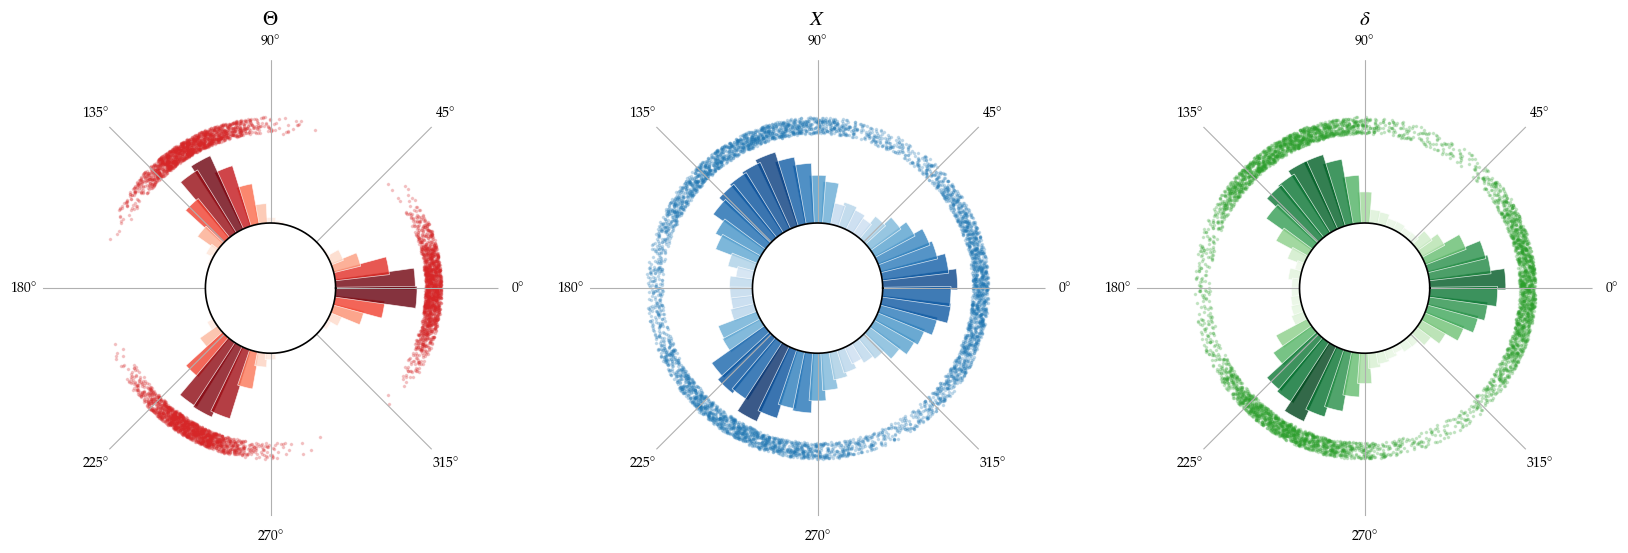

N : 0.22
D : 0.18
0.21


In [234]:
fig, axs = plt.subplots(1,3, figsize = (20,10), subplot_kw={'polar':True}, sharey=True)

size = 2.5; jitter_std = 5e-2; alpha = .2



S1_scatter(Theta, axs[0], 'C3', alpha, size, '$\Theta$', jitter_std)
S1_scatter(X, axs[1], 'C0', alpha, size, '$X$', jitter_std)
S1_scatter(delta, axs[2], 'C2', alpha, size, '$\delta$', jitter_std)

nbins = 50
S1_histogram(Theta, nbins, axs[0], 'Reds', '$\Theta$', .5)
S1_histogram(X, nbins, axs[1], 'Blues', '$X$', .5)
S1_histogram(delta, nbins, axs[2], 'Greens', '$\delta$', .5)
plt.show()

loss_N = (circle.metric.dist_broadcast(X, Theta)**2).mean()
loss_T = (circle.metric.dist_broadcast(delta, Theta)**2).mean()     

print('N : {:.2f}\nD : {:.2f}'.format(loss_N, loss_T))
print('{:.2f}'.format(1- loss_T/loss_N))

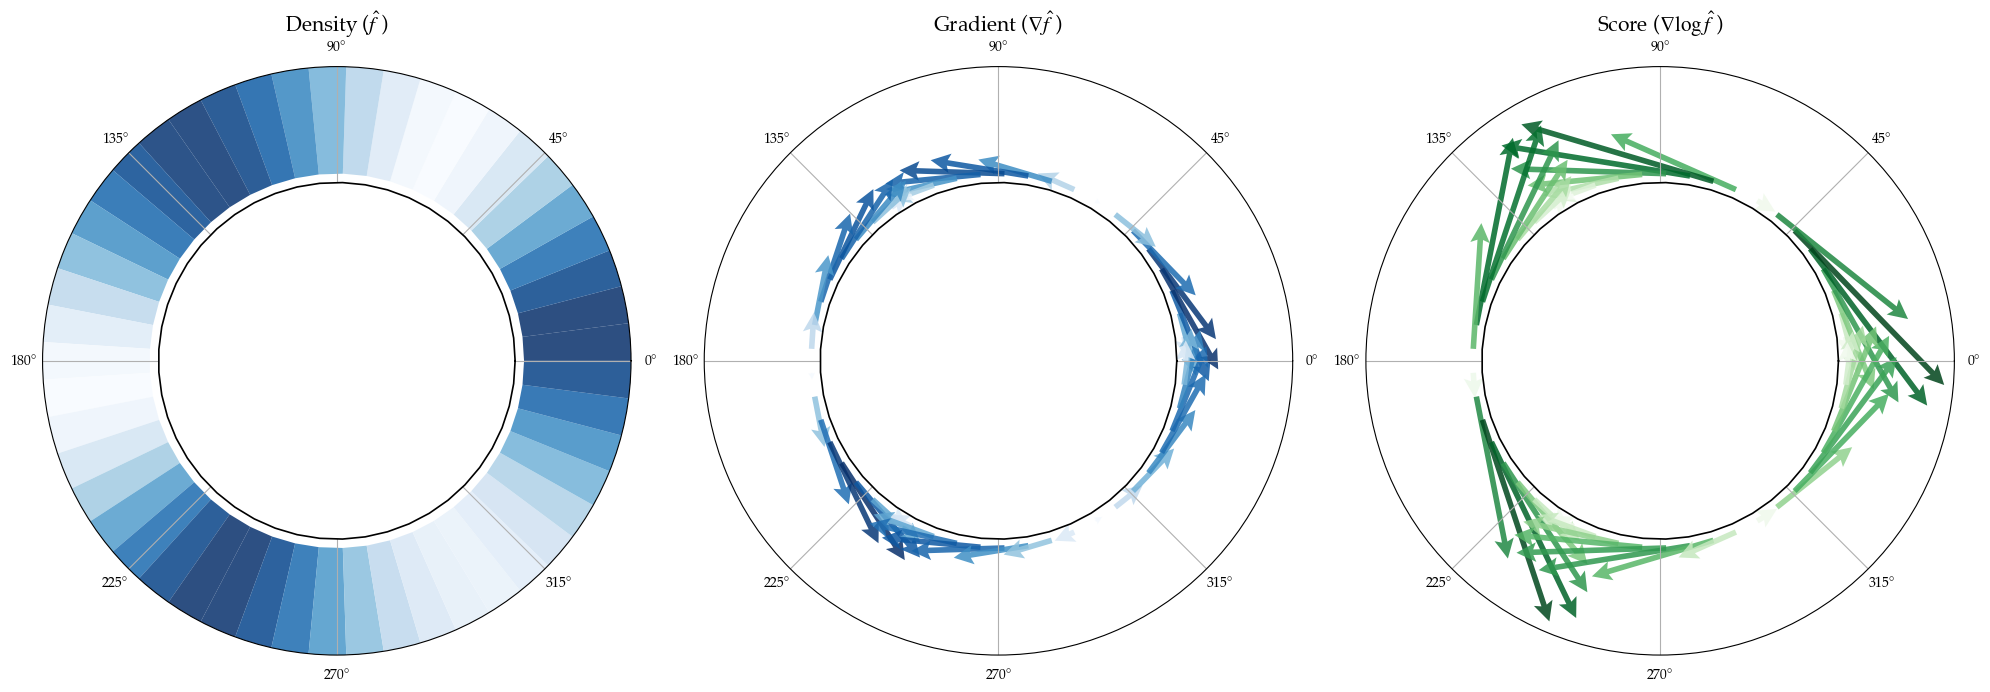

In [ ]:
grid_I = np.linspace(0, 2*np.pi, 50)
grid = np.stack([np.cos(grid_I), np.sin(grid_I)], axis=1)
_, hat_f, hat_grad_f = density_estimate('S1', X, M, grid)

tangent_vectors = hat_grad_f[:, None] * np.stack([-np.sin(grid_I), np.cos(grid_I)], axis=1)

fig, axs = plt.subplots(1, 3, figsize=(20, 10), subplot_kw={'polar': True})
f_scale = 0.3
bottom = 0.105
top = .5
disk_r = 0.1

# ---------- DENSITY ---------------------------------------------------------------------------
hat_pos_f = np.maximum(hat_f, 0)
normalised_hat_f = (hat_pos_f - hat_pos_f.min()) / (hat_pos_f.max() - hat_pos_f.min() + 1e-10)
verts = [[
        (grid_I[i], bottom),
        # (grid_I[i], bottom + f_scale * hat_pos_f[i]), (grid_I[i+1], bottom + f_scale * hat_pos_f[i+1]),
        (grid_I[i],top), (grid_I[i+1], bottom + top),
        (grid_I[i+1], bottom)
    ] for i in range(len(grid_I) - 1)] # Create polygon vertices for each segment
poly = PolyCollection(verts, facecolors=plt.colormaps['Blues'](normalised_hat_f[:-1]), 
                      alpha=0.85, edgecolors='none')
axs[0].add_collection(poly)
# axs[0].plot(grid_I, bottom + f_scale*hat_pos_f, color='darkblue', linewidth=.5, alpha=0.85)
axs[0].set_title('Density ($\hat f$)', fontsize=15)

# ---------- GRADIENT ---------------------------------------------------------------------------
vector_lengths = np.linalg.norm(tangent_vectors, axis=1)
axs[1].quiver(
    grid_I,                         
    np.ones_like(grid_I)*bottom,    
    tangent_vectors[:, 0],          
    tangent_vectors[:, 1],          
    vector_lengths,                 
    scale=4,           
    width=0.0095,         
    headwidth=3.5,        
    headlength=3.5,       
    headaxislength=3, 
    cmap='Blues',       
    alpha=0.85,         
    edgecolors=None,     
    linewidths=0.25,     
)
axs[1].set_title('Gradient ($\\nabla \hat f$)', fontsize=15)

# ---------- SCORE ---------------------------------------------------------------------------
hat_score = hat_grad_f / np.maximum(rho, hat_f)
tangent_vectors = hat_score[:, None] * np.stack([-np.sin(grid_I), np.cos(grid_I)], axis=1)

vector_lengths = np.linalg.norm(tangent_vectors, axis=1)
axs[2].quiver(
    grid_I,                         
    np.ones_like(grid_I)*bottom,    
    tangent_vectors[:, 0],          
    tangent_vectors[:, 1],          
    vector_lengths,                 
    scale=7,           
    width=0.0095,         
    headwidth=3.5,        
    headlength=3.5,       
    headaxislength=3, 
    cmap='Greens',       
    alpha=0.85,         
    edgecolors=None,     
    linewidths=0.25,     
)
axs[2].set_title('Score ($\\nabla \log \hat f$)', fontsize=15)

# -------------------------------------------------------------------------------------

# Set consistent limits and styling for both axes
for ax in axs: 
    ax.set_ylim(0, bottom + f_scale*.2)  # Set proper radial limits
    ax.set_yticks([])
    ax.bar(0, disk_r, width=2*np.pi, bottom=0, color="white", edgecolor="none", align="edge", zorder=3)
    ax.plot(grid_I, disk_r*np.ones_like(grid_I), color='black', linewidth=1.2, zorder=4)

plt.tight_layout()

plt.show()

<!-- # Visualisation -->

-----

In [235]:
from pathlib import Path
from PIL import Image

src = Path("tikz_S1_1.png")

# Try common image extensions if none provided
if src.suffix == "":
    for ext in [".png", ".pdf", ".jpg", ".jpeg", ".tif", ".tiff"]:
        cand = src.with_suffix(ext)
        if cand.exists():
            src = cand
            break

if not src.exists():
    raise FileNotFoundError(f"Could not find input figure at {src!s}")

img = Image.open(src)

# If it's a PDF, PIL will usually load the first page (requires poppler in many envs)
# Convert to RGB so saving to PNG is consistent
img = img.convert("RGB")

w, h = img.size
cuts = [0, w // 3, 2 * w // 3, w]  # equal horizontal spacing

out_dir = src.parent
stem = src.stem

parts = []
for k in range(3):
    box = (cuts[k], 0, cuts[k + 1], h)  # (left, upper, right, lower)
    part = img.crop(box)
    out_path = out_dir / f"{stem}_part{k+1}.png"
    part.save(out_path, dpi=(300, 300))
    parts.append(out_path)

parts

[PosixPath('tikz_S1_1_part1.png'),
 PosixPath('tikz_S1_1_part2.png'),
 PosixPath('tikz_S1_1_part3.png')]